In [1]:
# transactions.csv 컬럼 설명
# msno                    : 유저 고유 ID (한 유저가 여러 번 결제할 수 있어 이 테이블의 PK가 아님)
# payment_method_id       : 결제 수단 코드 (범주형 정수, 40종)
# payment_plan_days       : 결제 주기(일 단위, 예: 30일 정기결제)
# plan_list_price         : 정가 (신대만 달러, NTD)
# actual_amount_paid      : 실제 결제 금액 (할인/프로모션 시 plan_list_price보다 작을 수 있음)
# is_auto_renew           : 자동 갱신 여부 (1=자동갱신, 0=아님)
# transaction_date        : 결제(트랜잭션) 발생일 (YYYYMMDD)
# membership_expire_date  : 이 결제로 갱신된 멤버십 만료일 (YYYYMMDD)
# is_cancel               : 이 트랜잭션이 능동적 구독 취소인지 여부 (1=취소, 0=아님). is_churn과는 다른 개념

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 시각화 스타일
sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})

SERIES_1 = "#2a78d6"
SERIES_2 = "#eb6834"
CUTOFF_DATE = pd.Timestamp("2017-01-31")
pd.set_option("display.max_columns", None)

In [3]:
RAW_DIR = Path("../data/raw").resolve()
raw_df = pd.read_csv(RAW_DIR / "transactions.csv")
raw_df["transaction_date"] = pd.to_datetime(raw_df["transaction_date"], format="%Y%m%d")

# 원본은 2017-02-28까지 제공되지만, 모델 입력 피처에는 2017-01-31까지만 사용
post_cutoff_mask = raw_df["transaction_date"] > CUTOFF_DATE
df = raw_df.loc[~post_cutoff_mask].copy()

print(f"원본 shape: {raw_df.shape}")
print(f"원본 거래 기간: {raw_df['transaction_date'].min().date()} ~ {raw_df['transaction_date'].max().date()}")
print(f"관측 종료일 이후 제외 거래: {post_cutoff_mask.sum():,}건")
print(f"EDA 대상 shape: {df.shape}")
print(df.dtypes)

# 필터링 후 더 이상 필요 없는 전체 원본 객체를 해제해 메모리 절약
del raw_df, post_cutoff_mask
display(df.head())

원본 shape: (21547746, 9)
원본 거래 기간: 2015-01-01 ~ 2017-02-28
관측 종료일 이후 제외 거래: 908,263건
EDA 대상 shape: (20639483, 9)
msno                                 str
payment_method_id                  int64
payment_plan_days                  int64
plan_list_price                    int64
actual_amount_paid                 int64
is_auto_renew                      int64
transaction_date          datetime64[us]
membership_expire_date             int64
is_cancel                          int64
dtype: object


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,2015-09-30,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,2015-09-30,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,2015-09-30,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,2015-09-30,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,2015-09-30,20151121,0


In [4]:
print(f"메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"전체 행 수: {len(df):,}")
print(f"msno 고유값 수: {df['msno'].nunique():,}  (행 수보다 훨씬 적음 -> 1유저 다건 트랜잭션 구조)")
print()
txn_per_user = df.groupby("msno").size()
print("유저당 트랜잭션 건수 분포:")
print(txn_per_user.describe())

메모리 사용량: 2443.2 MB
전체 행 수: 20,639,483
msno 고유값 수: 2,330,992  (행 수보다 훨씬 적음 -> 1유저 다건 트랜잭션 구조)

유저당 트랜잭션 건수 분포:
count    2.330992e+06
mean     8.854377e+00
std      8.607386e+00
min      1.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      1.600000e+01
max      7.100000e+01
dtype: float64


In [5]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
msno,0,0.0
payment_method_id,0,0.0
payment_plan_days,0,0.0
plan_list_price,0,0.0
actual_amount_paid,0,0.0
is_auto_renew,0,0.0
transaction_date,0,0.0
membership_expire_date,0,0.0
is_cancel,0,0.0


In [6]:
dup_count = df.duplicated().sum()
print(f"완전 중복 행 수: {dup_count:,} ({dup_count/len(df)*100:.3f}%)")
df[df.duplicated(keep=False)].sort_values("msno").head(6)

완전 중복 행 수: 3,138 (0.015%)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
13833296,++8dXbkKMJ0rXwUc/m19lTVokEl3c9EfRKWmV6qP9jg=,41,30,99,99,1,2016-08-05,20160904,0
20514078,++8dXbkKMJ0rXwUc/m19lTVokEl3c9EfRKWmV6qP9jg=,41,30,99,99,1,2016-08-05,20160904,0
16528928,+20hE3Vvz3NxE18F/MV7RzarD5DWeWefd9zzb+9ejGU=,41,30,99,99,1,2016-04-16,20160515,0
20406589,+20hE3Vvz3NxE18F/MV7RzarD5DWeWefd9zzb+9ejGU=,41,30,99,99,1,2016-04-16,20160515,0
7674675,+5G1snABFXas2LPGl7Q/w1yI83fPR5nc8TDsvwY6W+Q=,41,30,99,99,1,2015-10-26,20151125,0
12896272,+5G1snABFXas2LPGl7Q/w1yI83fPR5nc8TDsvwY6W+Q=,41,30,99,99,1,2015-10-26,20151125,0


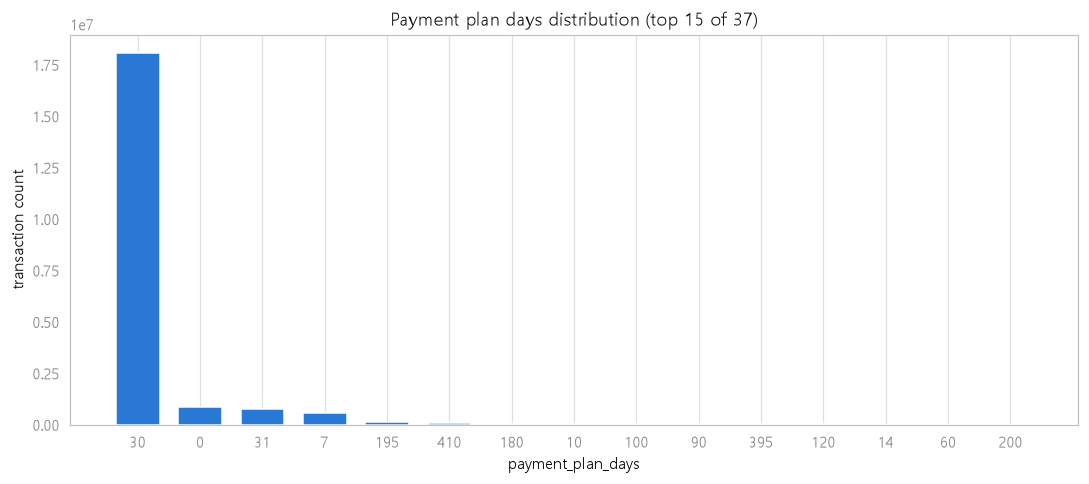

payment_plan_days
30     18050834
0        870124
31       766608
7        577439
195      110211
410       80111
180       52262
10        38133
100       24154
90        12310
395       10765
120        9630
14         6365
60         6320
200        5838
Name: count, dtype: int64

In [7]:
plan_days_counts = df["payment_plan_days"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plan_days_counts.index.astype(str), plan_days_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("payment_plan_days")
ax.set_ylabel("transaction count")
ax.set_title(f"Payment plan days distribution (top 15 of {df['payment_plan_days'].nunique()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

plan_days_counts

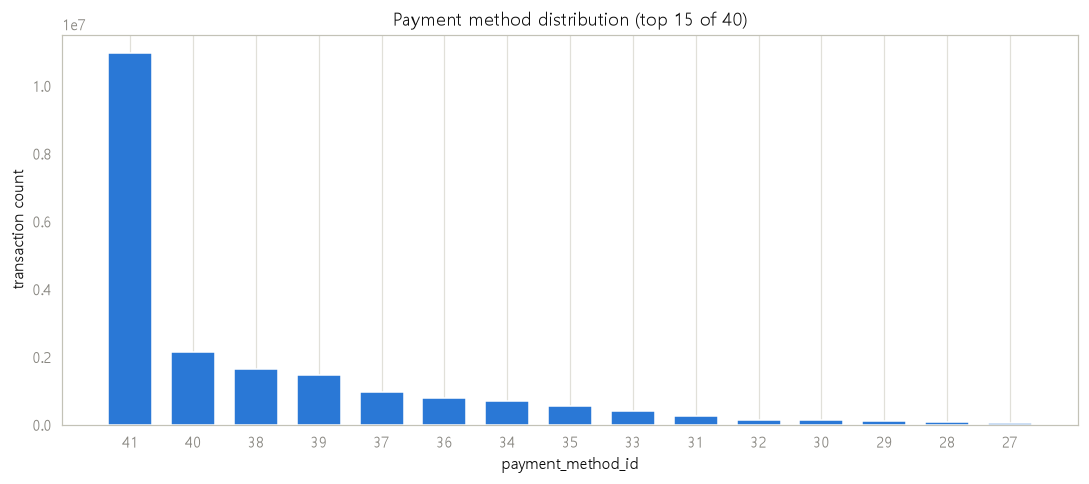

payment_method_id
41    10953642
40     2147272
38     1656503
39     1463739
37      968480
36      785926
34      703370
35      541395
33      398002
31      242528
32      146481
30      142357
29       95003
28       93894
27       60482
Name: count, dtype: int64

In [8]:
method_counts = df["payment_method_id"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(method_counts.index.astype(str), method_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("payment_method_id")
ax.set_ylabel("transaction count")
ax.set_title(f"Payment method distribution (top 15 of {df['payment_method_id'].nunique()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

method_counts

plan_list_price describe:
count    2.063948e+07
mean     1.404076e+02
std      1.336489e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: plan_list_price, dtype: float64

actual_amount_paid describe:
count    2.063948e+07
mean     1.426321e+02
std      1.351793e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: actual_amount_paid, dtype: float64


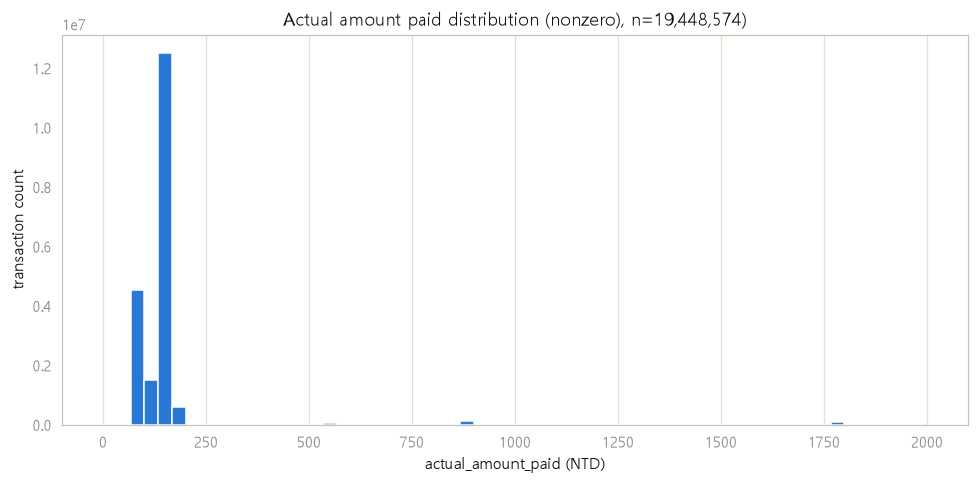

In [9]:
print("plan_list_price describe:"); print(df["plan_list_price"].describe())
print()
print("actual_amount_paid describe:"); print(df["actual_amount_paid"].describe())

paid_nonzero = df.loc[df["actual_amount_paid"] > 0, "actual_amount_paid"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(paid_nonzero, bins=60, color=SERIES_1)
ax.set_xlabel("actual_amount_paid (NTD)")
ax.set_ylabel("transaction count")
ax.set_title(f"Actual amount paid distribution (nonzero), n={len(paid_nonzero):,})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [10]:
discount_count = (df["plan_list_price"] > df["actual_amount_paid"]).sum()
free_count = (df["actual_amount_paid"] == 0).sum()

print(f"할인 결제 (정가 > 실결제액) 건수: {discount_count:,} ({discount_count/len(df)*100:.1f}%)")
print(f"0원 결제 (무료/프로모션 추정) 건수: {free_count:,} ({free_count/len(df)*100:.1f}%)")

할인 결제 (정가 > 실결제액) 건수: 853,075 (4.1%)
0원 결제 (무료/프로모션 추정) 건수: 1,190,909 (5.8%)


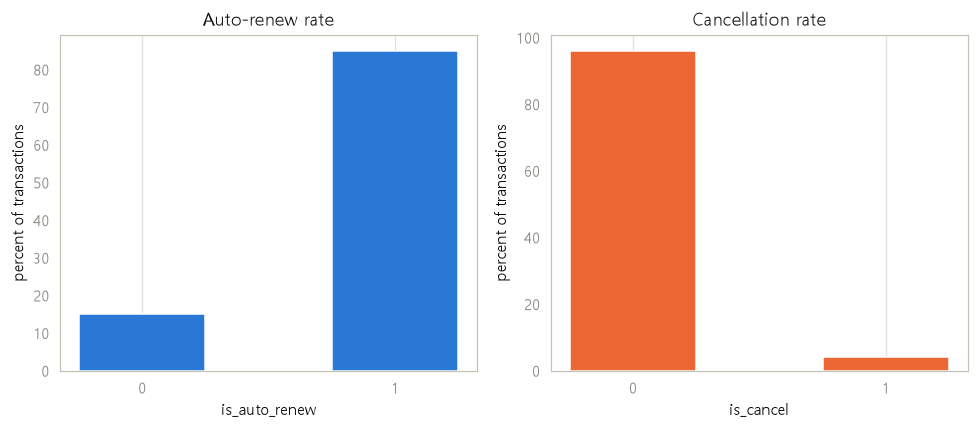

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

auto_renew_counts = df["is_auto_renew"].value_counts(normalize=True).sort_index() * 100
axes[0].bar(auto_renew_counts.index.astype(str), auto_renew_counts.values, color=SERIES_1, width=0.5)
axes[0].set_xlabel("is_auto_renew")
axes[0].set_ylabel("percent of transactions")
axes[0].set_title("Auto-renew rate")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

is_cancel_counts = df["is_cancel"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(is_cancel_counts.index.astype(str), is_cancel_counts.values, color=SERIES_2, width=0.5)
axes[1].set_xlabel("is_cancel")
axes[1].set_ylabel("percent of transactions")
axes[1].set_title("Cancellation rate")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

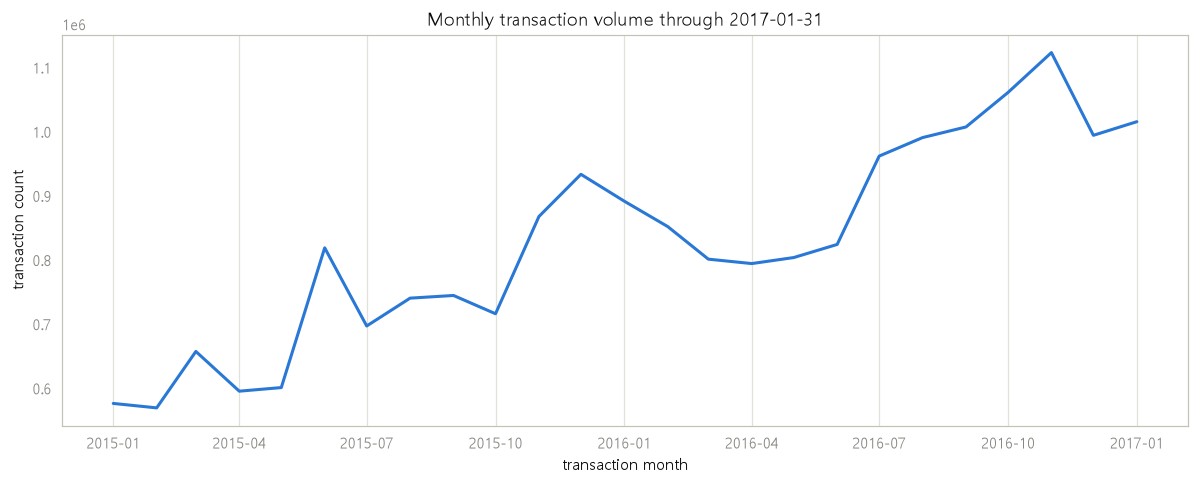

In [12]:
df["transaction_month"] = df["transaction_date"].dt.to_period("M")
monthly_txn = df.groupby("transaction_month").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_txn.index.to_timestamp(), monthly_txn.values, color=SERIES_1, linewidth=2)
ax.set_xlabel("transaction month")
ax.set_ylabel("transaction count")
ax.set_title(f"Monthly transaction volume through {CUTOFF_DATE.date()}")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [13]:
expire = df["membership_expire_date"]
print("membership_expire_date min/max:", expire.min(), expire.max())
print(f"1970-01-01(placeholder 추정) 건수: {(expire == 19700101).sum():,}")
print(f"2010-01-01 이전 이상치 건수: {(expire < 20100101).sum():,} ({(expire < 20100101).mean()*100:.4f}%)")

membership_expire_date min/max: 19700101 20170331
1970-01-01(placeholder 추정) 건수: 1,364
2010-01-01 이전 이상치 건수: 1,373 (0.0067%)


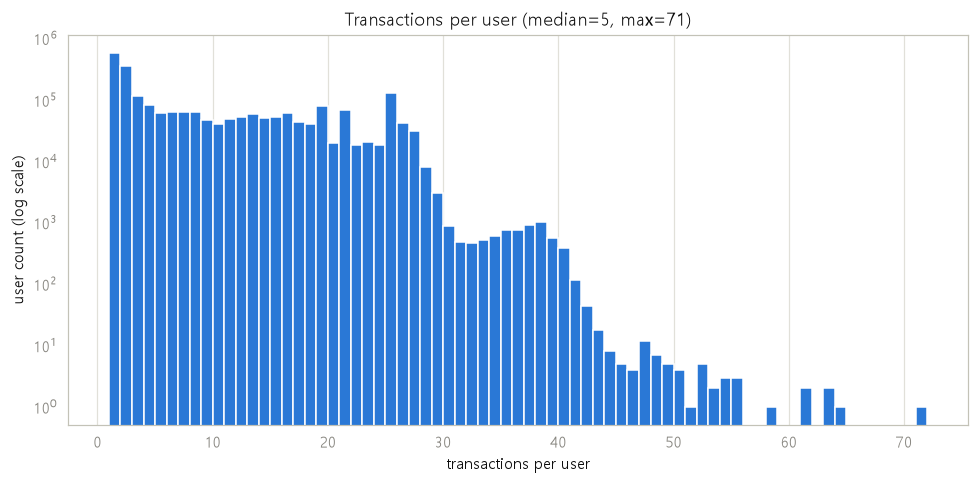

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(txn_per_user, bins=range(1, txn_per_user.max() + 2), color=SERIES_1)
ax.set_yscale("log")
ax.set_xlabel("transactions per user")
ax.set_ylabel("user count (log scale)")
ax.set_title(f"Transactions per user (median={txn_per_user.median():.0f}, max={txn_per_user.max()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [15]:
# ------------------------------------------------------------------
# 데이터 품질 이슈 요약 (전처리 단계에서 처리 필요)
# 1. 완전 중복 행 존재 -> 피처엔지니어링 전 drop_duplicates() 필요
# 2. membership_expire_date에 1970-01-01 등 비정상적으로 오래된 값 소수 존재 -> 이상치로 필터링 또는 결측 처리
# 3. actual_amount_paid == 0인 무료/프로모션성 결제가 약 5.5% 존재 -> 정상 결제와 구분되는 파생 플래그 고려
# 4. 이 테이블은 msno 기준 1:N 구조 -> 관측 종료일 2017-01-31 이전 거래만 유저 단위로 집계해야 한다.
#    원본에 포함된 2월 거래는 이탈 결과가 결정되는 미래 구간이므로 모델 입력 피처에서 제외한다.
# 5. is_auto_renew, is_cancel은 is_churn과 직접적으로 연관되는 핵심 후보 피처이나, 동일 개념이 아님에 유의
# ------------------------------------------------------------------
print("데이터 품질 이슈 요약 완료 (위 주석 참고)")

데이터 품질 이슈 요약 완료 (위 주석 참고)
